In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.formulas as fo
import src.network as net
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

c:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


{(0, 1, 0): 'AB', (1, 0, 0): 'BA', (1, 2, 0): 'BC', (1, 3, 0): 'BD', (2, 4, 0): 'CE', (2, 6, 0): 'CG', (3, 4, 0): 'DE', (3, 2, 0): 'DC', (4, 5, 0): 'EF', (4, 0, 0): 'EA', (6, 4, 0): 'GE', (6, 0, 0): 'GA', (5, 0, 0): 'FA'}


<AxesSubplot:>

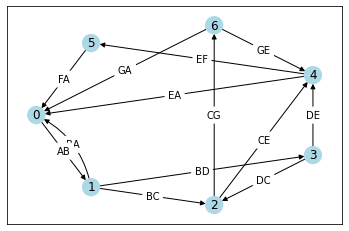

In [2]:
G = nx.MultiDiGraph()

edges = [
    (0, 1, {'w': 'AB'}), 
    (1, 0, {'w': 'BA'}),
    (1, 2, {'w': 'BC'}),
    (1, 3, {'w': 'BD'}),
    (3, 4, {'w': 'DE'}),
    (2, 4, {'w': 'CE'}),
    (2, 6, {'w': 'CG'}),
    (3, 2, {'w': 'DC'}),
    (4, 5, {'w': 'EF'}), 
    (6, 4, {'w': 'GE'}),
    (4, 0, {'w': 'EA'}),
    (6, 0, {'w': 'GA'}), 
    (5, 0, {'w': 'FA'})]
G.add_edges_from(edges)
net.plot_network(G)

Check if graph is suited for the the algorithm.

In [3]:
starting_node = 0
graph_suited = True

# check for absorbing states:
for out_degree in G.out_degree:
    if out_degree == 0:
        graph_suited = False

# check for reversible reactions and loops that do not contain the starting node
for cycle in nx.simple_cycles(G):
    print(cycle)
    if starting_node not in cycle:
        graph_suited = False

if graph_suited:
    print('graph is suited for the algorithm.')
else:
    print('graph is not suited for the algorithm.')

[0, 1]
[0, 1, 2, 4, 5]
[0, 1, 2, 4]
[0, 1, 2, 6, 4, 5]
[0, 1, 2, 6, 4]
[0, 1, 2, 6]
[0, 1, 3, 4, 5]
[0, 1, 3, 4]
[0, 1, 3, 2, 4, 5]
[0, 1, 3, 2, 4]
[0, 1, 3, 2, 6, 4, 5]
[0, 1, 3, 2, 6, 4]
[0, 1, 3, 2, 6]
graph is suited for the algorithm.


Determine the processing order of the graph's nodes. Each node with more than one incoming edge is ready to be processed only if all predecessors have already been processed.

In [4]:
degrees = G.in_degree

starting_node = 0
for node, degree in degrees:
    if degree > 1 and node != starting_node:
        print(node)
        print(list(G.predecessors(node)))

2
[1, 3]
4
[3, 2, 6]


In [5]:
# convert it to a directed acyclic graph
G_mutated = G
edges_to_remove = []
for edge in G.edges:
    if edge[1] == starting_node:
        edges_to_remove.append(edge)
G_mutated.remove_edges_from(edges_to_remove)
for state in nx.topological_sort(G_mutated):
    print(state)

0
1
3
2
6
4
5


In [10]:
fluorophore_system.distances

{}

In [27]:
print(transition_set.transition_df['initial_state'].apply(lambda x: x.value))

id
0     0
1     1
2     1
3     3
4     1
5     5
6     1
7     3
8     1
9     3
10    1
11    6
12    3
Name: initial_state, dtype: int64


In [3]:
reduced_set = transition_set.reduce()

In [8]:
reduced_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+05,False,False,None
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.383440e+05,False,False,None
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.383440e+06,False,False,None


In [2]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=10, count=1, shape='square', parameter_set='set 1')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(2.5, 640, bleaching=True)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=['OFRET', 'STA', 'HFRET', 'CFRET'])
transition_set = transition_set.adjust_rates({'BLE1': 2e2})
transition_set.finalize()
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+05,False,False,None
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None
7,TransitionType.ET_CYCLE_T,ETT,SingleState.T1,SingleState.S0,4.383440e+05,False,False,None
8,TransitionType.ET_CYCLE_S,ETS,SingleState.S1,SingleState.S0,4.383440e+06,False,False,None


In [4]:
prediction = st.Prediction(reduced_set)

In [5]:
simulation = si.Simulation(reduced_set)

In [6]:
simulation.approximate(prediction)

In [7]:
simulation.state_series

array([[0, 1, 0, ..., 0, 1, 0]], dtype=int8)

In [8]:
analysis = st.Analysis(simulation)

array([[<AxesSubplot:title={'center':'occurrences'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'lifetimes'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>,
        <AxesSubplot:title={'center':'occupation'}, ylabel='PR'>],
       [<AxesSubplot:title={'center':'transitions'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'time to transition'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='time to transition [s]', ylabel='PD'>,
        <AxesSubplot:>]], dtype=object)

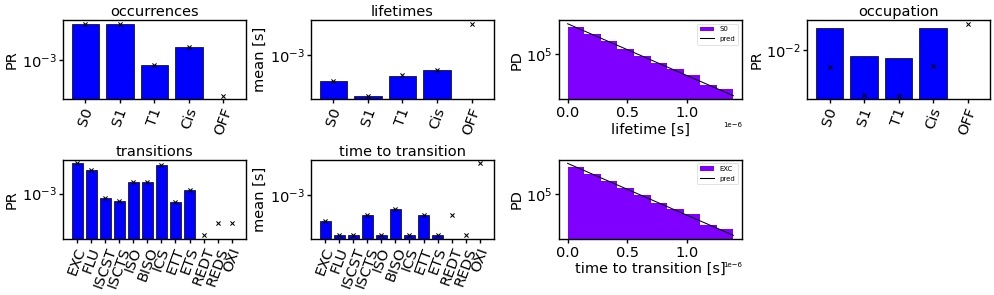

In [9]:
analysis.plot_all(prediction=prediction)

In [10]:
emissions = em.Emissions(simulation)

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

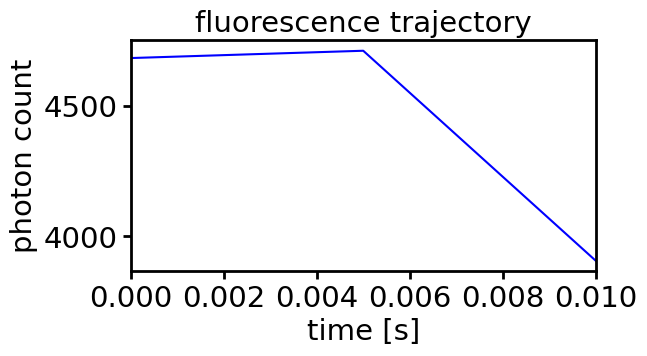

In [14]:
emissions.plot(mode='time_series', xlim=[0, 0.01])